In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from src.SizeEffects_functions import linear_regression_weighted
from matplotlib.collections import LineCollection
from src.process_data import  process_all_data, create_folder
from src.results_paper import *
from src.TimeSeriesAnalysis import *
from src.process_data import process_all_roots, summarize_all_dirs
from IPython.display import clear_output
from matplotlib.lines import Line2D
from matplotlib.ticker import AutoMinorLocator
plt.style.use('properties.mplstyle')

In [6]:
results_folder = "../results/Navigation/3D"
path_sizes = "../results/size_effects/3D"

create_folder(results_folder)
create_folder(path_sizes)

In [13]:
process_all_data(clear_data=False)

Processamento finalizado.


In [7]:
df = pd.read_csv("../Data/bond_percolation/all_data.dat", sep=',').sort_values('rho').reset_index(drop=True)
df = df[df['dim']==3]
df

,dim,L,Nt,k,nc,rho,p0,P0,order,N_samples,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
0,3,1024,3000,0.000001,4,0.001000,1.0,1.0,1,10,0.249469,0.000084,8640.200000,220.007717,2.838504e+07,5.282409e+05
1,3,1024,3000,0.000001,4,0.001000,1.0,1.0,2,10,0.249581,0.000084,9017.500000,200.162170,2.838609e+07,5.282862e+05
2,3,1024,3000,0.000001,4,0.001000,1.0,1.0,3,10,0.249576,0.000086,8919.500000,158.944522,2.838602e+07,5.280366e+05
3,3,1024,3000,0.000001,4,0.001000,1.0,1.0,4,10,0.249617,0.000122,9236.500000,176.047926,2.838491e+07,5.277714e+05
4,3,1024,3000,0.000001,4,0.006005,1.0,0.1,1,10,0.249410,0.000008,8509.400000,226.308550,2.765863e+07,6.239480e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13902,3,360,3000,0.000001,2,0.500000,1.0,0.1,1,75,0.252171,0.000009,1540.426667,6.645114,5.445592e+06,1.860736e+04
13903,3,296,3000,0.000001,2,0.500000,1.0,0.1,1,100,0.254172,0.000011,1055.400000,3.136201,3.933164e+06,9.028256e+03
13904,3,1024,3000,0.000001,1,1.000000,1.0,0.1,1,10,0.248962,0.000007,11736.500000,556.178094,3.536131e+07,1.676786e+06
13905,3,512,3000,0.000001,1,1.000000,1.0,0.1,1,30,0.249579,0.000009,3487.266667,77.043560,1.114699e+07,2.374546e+05


In [20]:
df_s = df[df['nc']==4]['L'].unique()
df_s

array([1024,  512,  384,  256,  192,  128])

In [19]:
L_alvo = [ 512,  256,  128, 192, 1024]
nc = 2

df_f = df[(df["L"].isin(L_alvo)) & (df["nc"] == nc)].copy()

# ajuste o número de casas conforme seu dataset (10–12 costuma bastar)
df_f["rho_key"] = df_f["rho"].round(12)

rhos_comuns = (
    df_f.groupby("rho_key")["L"]
        .nunique()
        .loc[lambda s: s == len(L_alvo)]
        .index
)

df_comum = df_f[df_f["rho_key"].isin(rhos_comuns)].copy()

# se você quer ver os valores "originais" de rho correspondentes:
df_comum["rho"].unique()

with np.printoptions(threshold=np.inf):
    print(df_comum["rho_key"].unique().tolist())
    print(len(df_comum["rho_key"].unique().tolist()))

[0.125]
1


In [15]:
df.head()

,dim,L,Nt,k,nc,rho,p0,P0,order,N_samples,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
0,3,1024,3000,0.000001,4,0.001000,1.0,1.0,1,10,0.249340,0.000007,8640.2,220.007717,28385039.3,528240.943520
1,3,1024,3000,0.000001,4,0.001000,1.0,1.0,2,10,0.249459,0.000007,9017.5,200.162170,28386085.9,528286.233549
2,3,1024,3000,0.000001,4,0.001000,1.0,1.0,3,10,0.249516,0.000008,8919.5,158.944522,28386018.4,528036.591525
3,3,1024,3000,0.000001,4,0.001000,1.0,1.0,4,10,0.249544,0.000008,9236.5,176.047926,28384908.2,527771.393318
4,3,1024,3000,0.000001,4,0.006005,1.0,0.1,2,10,0.249439,0.000008,8692.8,237.853400,27656187.8,622644.031575


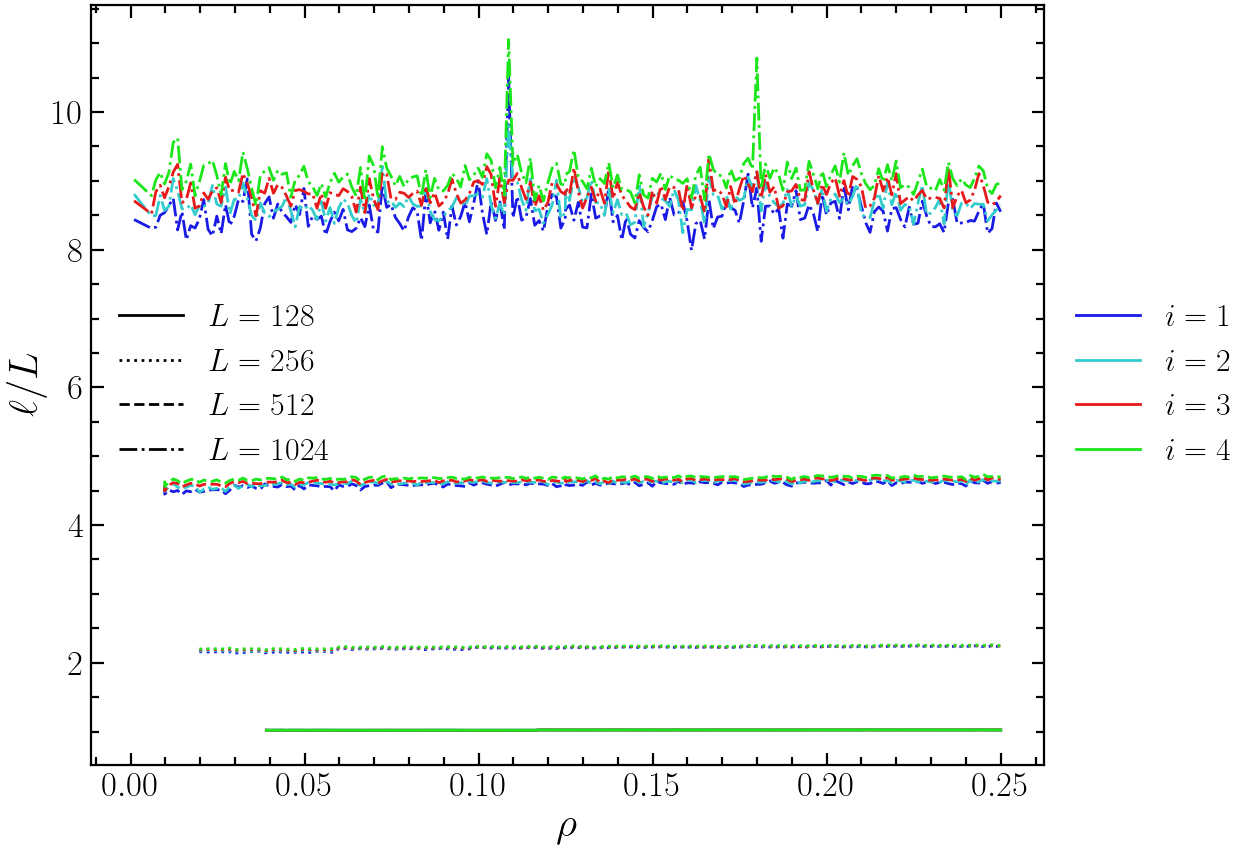

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

L_lst = [128, 256, 512, 1024]
nc = 4
orders = [i for i in range(1, nc+1)]

colors = [
    (0.1, 0.1, 0.9),  # blue
    (0.2, 0.8, 0.8),  # teal
    (0.9, 0.1, 0.1),  # red
    (0.1, 0.9, 0.1),  # green
]
fs_legend_global = 23
fs_legend_local = 23
fs_ticks = 25
fs_labels = 30
lw_data = 2.0

tick_w = 1.6


ls = ['solid', 'dotted', 'dashed', 'dashdot']

fig, ax = plt.subplots(figsize=(13, 9))



# ======================
# Plot
# ======================
for idx, L in enumerate(L_lst):
    for idx_c, ord in enumerate(orders):
        df_sub = df[(df["L"]==L) & (df['nc']==nc) & (df['order']==ord)]
        
        x = np.asarray(df_sub['rho'])
        y = np.asarray(df_sub['shortest_path']/L)
        y_err = np.asarray(df_sub['shortest_path_err']/L)
        
        
        ax.plot(
            df_sub['rho'],
            df_sub['shortest_path']/L,
            ls=ls[idx],
            color=colors[idx_c],
            lw=lw_data
        )

ax.set_ylabel(r"$\ell/L$",fontsize=fs_labels)
ax.set_xlabel(r"$\rho$",fontsize=fs_labels)

# ======================
# Legenda interna → L (linestyle, preto)
# ======================
legend_L = [
    Line2D([0], [0],
           color='black',
           linestyle=ls[i],
           lw=lw_data,
           label=fr"$L={L_lst[i]}$")
    for i in range(len(L_lst))
]

leg1 = ax.legend(
    handles=legend_L,
#    loc='upper left',
    frameon=False,
    fontsize=fs_legend_local
)

# ======================
# Legenda externa → ordem i (cores)
# ======================
legend_i = [
    Line2D([0], [0],
           color=colors[i],
           lw=lw_data,
           label=fr"$i={orders[i]}$")
    for i in range(len(orders))
]

leg2 = ax.legend(
    handles=legend_i,
    bbox_to_anchor=(1.02, 0.5),   # x fora, y central
    loc='center left',
    borderaxespad=0.,
    frameon=False,
    fontsize=fs_legend_global
)

ax.tick_params(axis='both', which='both', width=tick_w, labelsize=fs_ticks)
ax.add_artist(leg1)
for spine in ax.spines.values():
    spine.set_linewidth(tick_w)

plt.tight_layout()
plt.savefig(path_sizes + "/shortest_from_rho.pdf")
plt.show()

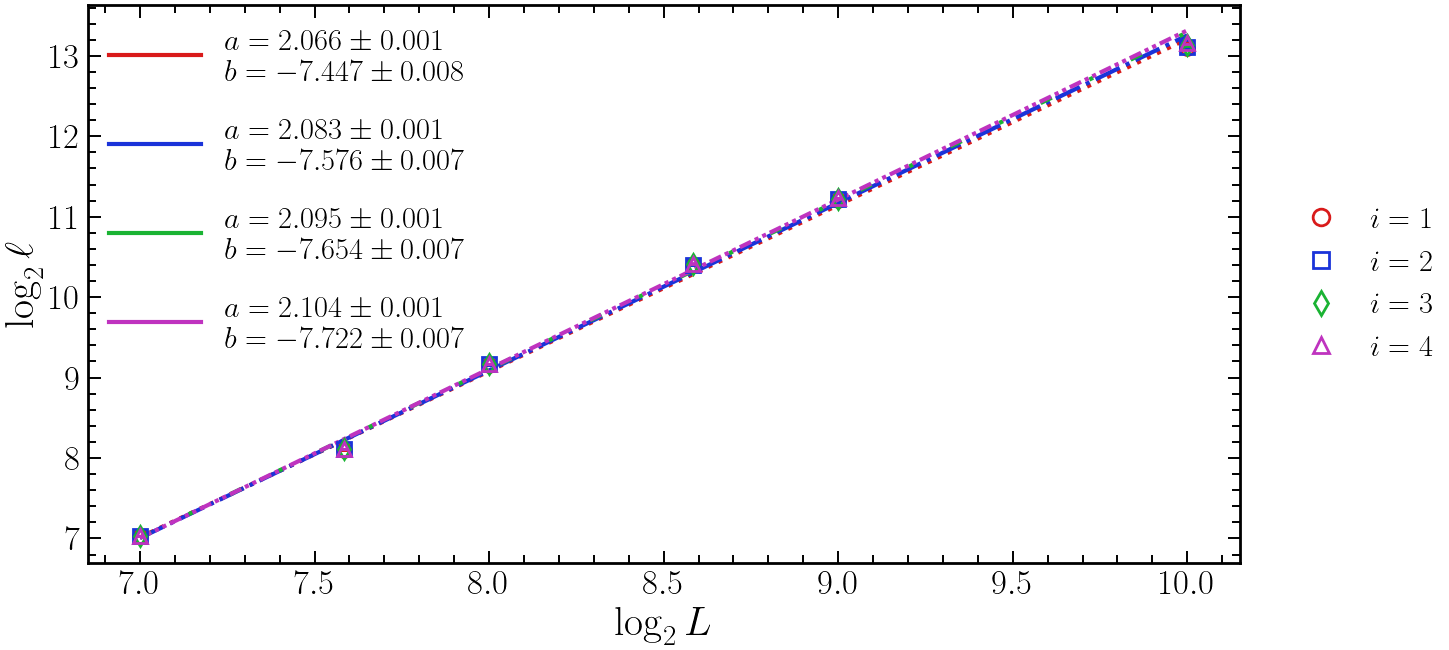

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit

def log2_with_error(val, err):
    val = np.asarray(val, dtype=float)
    err = np.asarray(err, dtype=float)
    y = np.log2(val)
    y_err = err / (val * np.log(2))
    return y, y_err

def fit_linear_weighted(x, y, y_err):
    def linear(x, a, b):
        return a * x + b
    popt, pcov = curve_fit(linear, x, y, sigma=y_err, absolute_sigma=True)
    a, b = popt
    sigma_a, sigma_b = np.sqrt(np.diag(pcov))
    return a, b, sigma_a, sigma_b

def extract_shortest_path_data(df, L_lst, nc, ord, rho=None):
    if rho is None:
        rho = 1 / nc

    short = []
    short_err = []
    for L in L_lst:
        df_sub = df[
            (df["L"] == L) &
            (df["nc"] == nc) &
            (df["order"] == ord) &
            (df["rho"] == rho)
        ]
        if df_sub.empty:
            raise ValueError(f"Sem dados para L={L}, nc={nc}, ord={ord}, rho={rho}")

        short.append(df_sub["shortest_path"].values[0])
        short_err.append(df_sub["shortest_path_err"].values[0])

    return np.asarray(L_lst, float), np.asarray(short, float), np.asarray(short_err, float)

def plot_all_orders_together_two_legends(
    df, L_lst, nc,
    orders=None, rho=None,
    figsize=(9, 7),
    fs_ticks=25, fs_labels=30,
    fs_leg_out=22, fs_leg_in=22,
    lw_data=0.0,   # marcador-only (como seu exemplo)
    lw_fit=3.0,
    capsize=4
):
    if orders is None:
        orders = [i for i in range(1, nc+1)]
    if rho is None:
        rho = 1 / nc

    # cores (se quiser tudo preto, troque por ['k']*len(orders))
    colors = [
        (0.85, 0.1, 0.1),
        (0.1, 0.2, 0.85),
        (0.1, 0.7, 0.2),
        (0.75, 0.2, 0.75),
    ]

    # símbolos diferentes para cada i (como no seu exemplo 2)
    markers = ['o', 's', 'd', '^']  # círculo, quadrado, losango, triângulo

    fig, ax = plt.subplots(figsize=figsize)

    x = np.log2(np.asarray(L_lst, dtype=float))
    x_fit = np.linspace(x.min(), x.max(), 400)

    # --- handles/labels para as duas legendas ---
    handles_out, labels_out = [], []  # fora: i = ...
    handles_in, labels_in = [], []    # dentro: a,b...

    for idx, ord in enumerate(orders):
        c = colors[idx % len(colors)]
        m = markers[idx % len(markers)]

        L, short, short_err = extract_shortest_path_data(df, L_lst, nc, ord, rho=rho)
        y, y_err = log2_with_error(short, short_err)

        a, b, sigma_a, sigma_b = fit_linear_weighted(x, y, y_err)

        # pontos (marcador vazio com borda colorida, como exemplo)
        ax.errorbar(
            x, y, yerr=y_err,
            fmt=m,
            ms=10,
            mfc='none',
            mec=c,
            mew=2.0,
            ecolor=c,
            elinewidth=1.8,
            capsize=capsize,
            lw=lw_data
        )

        # reta do fit
        ax.plot(x_fit, a*x_fit + b, color=c, lw=lw_fit)

        # -------- legenda fora (somente símbolos + i) --------
        handles_out.append(Line2D([0], [0], marker=m, linestyle='None',
                                  markerfacecolor='none', markeredgecolor=c,
                                  markeredgewidth=2.0, markersize=12))
        labels_out.append(rf"$i= {ord}$")

        # -------- legenda dentro (somente a e b, com a mesma cor da reta) --------
        handles_in.append(Line2D([0], [0], color=c, lw=lw_fit))
        labels_in.append(
            rf"$a={a:.3f}\pm{sigma_a:.3f}$" "\n"
            rf"$b={b:.3f}\pm{sigma_b:.3f}$"
        )

    ax.set_xlabel(r"$\log_2 L$", fontsize=fs_labels)
    ax.set_ylabel(r"$\log_2 \ell$", fontsize=fs_labels)
    ax.tick_params(axis='both', which='major', labelsize=fs_ticks)

    # --- legenda interna: parâmetros (dentro) ---
    leg_in = ax.legend(
        handles_in, labels_in,
        loc="upper left",
        fontsize=fs_leg_in,
        frameon=False,
        handlelength=3.0,
        labelspacing=1.0,
        borderpad=0.2
    )
    ax.add_artist(leg_in)

    # --- legenda externa: i (fora) ---
    ax.legend(
        handles_out, labels_out,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=fs_leg_out,
        frameon=False,
        handletextpad=0.6
    )

    fig.tight_layout()
    return fig, ax


# =========================
# USO
# =========================
nc = 4
orders = [i for i in range(1, nc+1)]
L_lst = [128, 192, 256, 384, 512, 1024]
rho = 1/nc

fig, ax = plot_all_orders_together_two_legends(
    df=df, L_lst=L_lst, nc=nc, orders=orders, rho=rho,
    figsize=(15, 7),
    fs_ticks=25, fs_labels=30,
    fs_leg_out=22, fs_leg_in=22,
    lw_fit=3.0
)
plt.savefig(results_folder + "/shortest_versus_L.png")
plt.show()


In [95]:
df.head()

,dim,L,Nt,k,nc,rho,p0,P0,order,N_samples,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
0,3,1024,3000,0.000001,4,0.001000,1.0,1.0,1,10,0.249340,0.000007,8640.2,220.007717,28385039.3,528240.943520
1,3,1024,3000,0.000001,4,0.001000,1.0,1.0,2,10,0.249459,0.000007,9017.5,200.162170,28386085.9,528286.233549
2,3,1024,3000,0.000001,4,0.001000,1.0,1.0,3,10,0.249516,0.000008,8919.5,158.944522,28386018.4,528036.591525
3,3,1024,3000,0.000001,4,0.001000,1.0,1.0,4,10,0.249544,0.000008,9236.5,176.047926,28384908.2,527771.393318
4,3,1024,3000,0.000001,4,0.006005,1.0,0.1,2,10,0.249439,0.000008,8692.8,237.853400,27656187.8,622644.031575


In [6]:
df[(df['rho']==0.125) & (df['dim']==3) & (df['nc']==8)]['L'].unique()


array([1024,  256,  512,  768,  128,  384,  192])

In [3]:
import numpy as np

def linear_regression_weighted(x, y, y_err, scale_by_chi2=True, eps=1e-15):
    """
    Regressão linear ponderada.
    Modelo: y = A x + B

    Se scale_by_chi2=True:
      - multiplica as incertezas dos parâmetros por sqrt(chi2_red) quando dof>0,
        o que corrige subestimação quando y_err não bate com a dispersão real.

    Retorna:
    A, B, sigma_A, sigma_B, chi2, chi2_red, R2, y_fit, cov
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    y_err = np.asarray(y_err, dtype=float)

    # proteção
    y_err = np.maximum(y_err, eps)

    w = 1.0 / (y_err**2)

    S   = np.sum(w)
    Sx  = np.sum(w * x)
    Sy  = np.sum(w * y)
    Sxx = np.sum(w * x * x)
    Sxy = np.sum(w * x * y)

    Delta = S * Sxx - Sx**2
    if not np.isfinite(Delta) or Delta <= 0:
        raise ValueError("Delta inválido (problema numérico/degenerescência).")

    A = (S * Sxy - Sx * Sy) / Delta
    B = (Sxx * Sy - Sx * Sxy) / Delta

    y_fit = A * x + B

    # χ²
    chi2 = np.sum(w * (y - y_fit)**2)
    dof = len(x) - 2
    chi2_red = chi2 / dof if dof > 0 else np.nan

    # covariância (X^T W X)^-1 para [A, B]
    cov = np.array([[ S / Delta,   -Sx / Delta],
                    [-Sx / Delta,  Sxx / Delta]], dtype=float)

    # escala por chi2_red (se desejado e dof válido)
    if scale_by_chi2 and (dof > 0) and np.isfinite(chi2_red) and (chi2_red > 0):
        cov = cov * chi2_red

    sigma_A = float(np.sqrt(cov[0, 0]))
    sigma_B = float(np.sqrt(cov[1, 1]))

    # R² ponderado
    y_mean_w = Sy / S
    chi2_tot = np.sum(w * (y - y_mean_w)**2)
    R2 = 1.0 - chi2 / chi2_tot if chi2_tot > 0 else np.nan

    return A, B, sigma_A, sigma_B, chi2, chi2_red, R2, y_fit, cov

# $N_c = 8$

['$384$', '$416$', '$448$', '$480$', '$512$', '$600$', '$680$', '$768$', '$1024$']
['$150$', '$150$', '$100$', '$100$', '$50$', '$20$', '$20$', '$31$', '$10$']
   order              A      sigma_A         B   sigma_B        nu        R²
0      1  231187.031538  1121.827510  0.249173  0.000043  2.766667  0.999835
1      2  163006.596557  1127.267432  0.249078  0.000063  2.706061  0.999665
2      3  235084.370365   830.003186  0.249120  0.000031  2.766667  0.999913
3      4  235267.414180  1894.165040  0.249110  0.000072  2.766667  0.999546
4      5  338276.681315  1929.582553  0.249234  0.000051  2.827273  0.999772
5      6  233979.256485  1338.159850  0.249153  0.000051  2.766667  0.999771
6      7  479086.042925  1644.061211  0.249420  0.000030  2.887879  0.999918
7      8  161631.819634   824.772864  0.249103  0.000046  2.706061  0.999818
exp = 2.7742424242424244


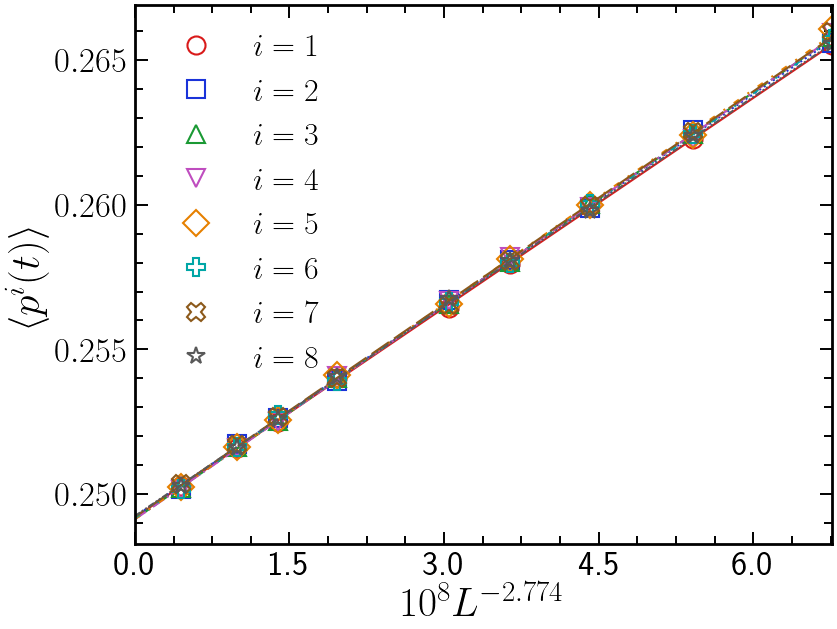

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, MaxNLocator

# =========================
# Inputs
# =========================
L_lst = [384, 416, 448, 480, 512, 600, 680, 768, 1024]
nc = 8
rho = 1/nc

fs_legend_global = 23
fs_legend_local = 23
fs_ticks = 25
fs_labels = 30
mew = 1.5
ms = 13
tick_w = 1.6

markers = [
    "o", "s", "^", "v", "D", "P", "X", "*"
]

colors = [
    (0.85, 0.10, 0.10),  # vermelho forte
    (0.10, 0.20, 0.85),  # azul forte
    (0.10, 0.60, 0.20),  # verde escuro
    (0.75, 0.30, 0.75),  # magenta
    (0.90, 0.50, 0.00),  # laranja forte
    (0.00, 0.65, 0.65),  # ciano escuro
    (0.55, 0.35, 0.10),  # marrom
    (0.35, 0.35, 0.35),  # cinza escuro
]

ls = ['solid', 'dotted', 'dashed', 'dashdot', (0, (3, 5, 1, 5)),
      (0, (3, 10, 1, 10)), (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1)),
      (0, (3, 10, 1, 10, 1, 10))]

orders = [i for i in range(1, nc + 1)]

l_latex = []
ns_latex = []

fig, ax = plt.subplots(figsize=(9, 7))

l = np.asarray([1/i for i in L_lst], float)

data_pi = {"order": [], "L_lst": [], "pc": [], "pc_err": []}

data = {"order": [], "A": [], "sigma_A": [], "B": [], "sigma_B": [], "nu": [], "R²": []}
nu = np.linspace(0.1, 6.1, 100)

# =========================
# Scan em nu para achar melhor por order
# =========================
for idx, ord in enumerate(orders):

    pc_lst = []
    pc_err_lst = []

    for L in L_lst:
        df_sub = df[(df['L'] == L) & (df['nc'] == nc) & (df['rho'] == rho) & (df['order'] == ord)]

        pc_lst.append(df_sub['p_mean'].values[0])
        pc_err_lst.append(df_sub['p_err'].values[0])

        if ord == 1:
            l_latex.append(f'${L}$')
            ns_latex.append(f'${int(df_sub['N_samples'].values[0])}$')

    pc_lst = np.asarray(pc_lst, float)
    pc_err_lst = np.asarray(pc_err_lst, float)

    for ni in nu:
        x = np.asarray([1 / (L**ni) for L in L_lst], float)
        y = pc_lst
        y_err = pc_err_lst

        parms = linear_regression_weighted(x, y, y_err)
        A, B, sigma_A, sigma_B, R2 = parms[0], parms[1], parms[2], parms[3], parms[6]

        data["order"].append(ord)
        data["nu"].append(ni)
        data["R²"].append(R2)
        data["A"].append(A)
        data["B"].append(B)
        data["sigma_A"].append(sigma_A)
        data["sigma_B"].append(sigma_B)

print(l_latex)
print(ns_latex)

df_new = pd.DataFrame(data=data)

df_best_per_order = (
    df_new.loc[df_new.groupby("order")["R²"].idxmax()]
          .sort_values("order")
          .reset_index(drop=True)
)

print(df_best_per_order)

exp = df_best_per_order['nu'].mean()
print("exp =", exp)

# =========================
# Scaling do eixo x: x_scaled = 10^power * L^{-exp}
# =========================
power = 8
scale = 10**power

x_base = l**exp
x_scaled = x_base * scale
x_max = float(np.max(x_scaled))

# =========================
# Plot final
# =========================
for idx, ord in enumerate(orders):

    pc_lst = []
    pc_err_lst = []

    for L in L_lst:
        df_sub = df[(df['L'] == L) & (df['nc'] == nc) & (df['rho'] == rho) & (df['order'] == ord)]
        pc_lst.append(df_sub['p_mean'].values[0])
        pc_err_lst.append(df_sub['p_err'].values[0])

    pc = np.asarray(pc_lst, float)
    pc_err = np.asarray(pc_err_lst, float)

    data_pi['order'].append(ord)
    data_pi['L_lst'].append(l)
    data_pi['pc'].append(pc)
    data_pi['pc_err'].append(pc_err)

    parms = linear_regression_weighted(x_scaled, pc, pc_err)

    x_fit = np.linspace(0, x_max, 500)
    y_fit = parms[0] * x_fit + parms[1]

    ax.plot(x_fit, y_fit, ls=ls[idx], color=colors[idx])
    ax.plot(x_scaled, pc, linestyle='none', ms=ms, mew=mew,
            marker=markers[idx], color=colors[idx], label=f'$i = {ord}$')

df_pi = pd.DataFrame(data=data_pi)

# =========================
# Ticks bonitos: 0.0, 0.5, 1.0, ...
# =========================
ax.xaxis.set_major_locator(MaxNLocator(6))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.xaxis.offsetText.set_visible(False)

ax.set_xlim([0, x_max])

ax.set_xlabel(fr"$10^{{{power}}}L^{{-{exp:.3f}}}$", fontsize=fs_labels)
ax.set_ylabel(r"$\langle p^i(t) \rangle$", fontsize=fs_labels)

ax.legend(fontsize=fs_legend_local)
ax.tick_params(axis='both', which='major', labelsize=fs_ticks)
plt.savefig(path_sizes + f"/L_versus_p_nc_{nc}.pdf")
plt.show()

# $N_c = 4$

   order             A     sigma_A         B   sigma_B        nu        R²
0      1  63828.392379  291.267809  0.248995  0.000034  2.706061  0.999854
1      2  90708.465806  349.209663  0.249118  0.000028  2.766667  0.999896
2      3  64713.119821  363.485860  0.249036  0.000041  2.706061  0.999779
3      4  91882.379694  485.162284  0.249097  0.000039  2.766667  0.999805
exp = 2.7363636363636368
['$256$', '$283$', '$320$', '$348$', '$384$', '$443$', '$512$', '$768$', '$1024$']
['$350$', '$200$', '$200$', '$130$', '$171$', '$60$', '$80$', '$30$', '$21$']


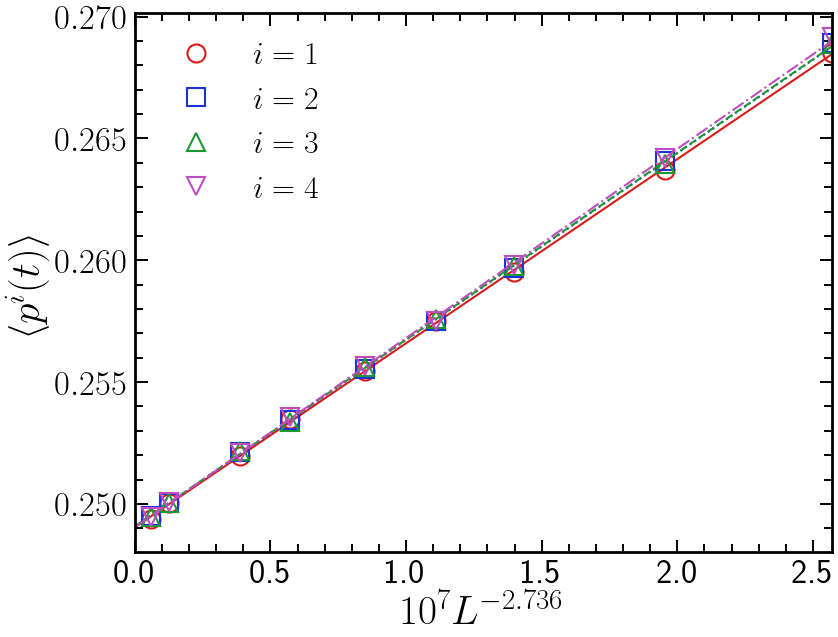

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, MaxNLocator

# =========================
# Inputs
# =========================
L_lst = [256, 283, 320, 348, 384, 443, 512, 768, 1024]
nc = 4
rho = 1/nc

fs_legend_global = 23
fs_legend_local = 23
fs_ticks = 25
fs_labels = 30
mew = 1.5
ms = 13
tick_w = 1.6

markers = ["o", "s", "^", "v", "D", "P", "X", "*"]

ls = ['solid', 'dotted', 'dashed', 'dashdot', (0, (3, 5, 1, 5)),
      (0, (3, 10, 1, 10)), (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1)),
      (0, (3, 10, 1, 10, 1, 10))]

colors = [
    (0.85, 0.10, 0.10),
    (0.10, 0.20, 0.85),
    (0.10, 0.60, 0.20),
    (0.75, 0.30, 0.75),
    (0.90, 0.50, 0.00),
    (0.00, 0.65, 0.65),
    (0.55, 0.35, 0.10),
    (0.35, 0.35, 0.35),
]

orders = [i for i in range(1, nc + 1)]

fig, ax = plt.subplots(figsize=(9, 7))

l = np.asarray([1/i for i in L_lst], float)

data_pi = {"order": [], "L_lst": [], "pc": [], "pc_err": []}

data = {"order": [], "A": [], "sigma_A": [], "B": [], "sigma_B": [], "nu": [], "R²": []}
nu = np.linspace(0.1, 6.1, 100)

l_latex = []
ns_latex = []

# =========================
# Scan em nu para achar melhor por order
# =========================
for idx, ord in enumerate(orders):
    pc_lst = []
    pc_err_lst = []

    for L in L_lst:
        df_sub = df[(df['L'] == L) & (df['nc'] == nc) & (df['rho'] == rho) & (df['order'] == ord)]

        pc_lst.append(df_sub['p_mean'].values[0])
        pc_err_lst.append(df_sub['p_err'].values[0])

        if ord == 1:
            l_latex.append(L)
            ns_latex.append(int(df_sub['N_samples'].values[0]))

    pc_lst = np.asarray(pc_lst, float)
    pc_err_lst = np.asarray(pc_err_lst, float)

    for ni in nu:
        x = np.asarray([1 / (L**ni) for L in L_lst], float)
        y = pc_lst
        y_err = pc_err_lst

        parms = linear_regression_weighted(x, y, y_err)
        A, B, sigma_A, sigma_B, R2 = parms[0], parms[1], parms[2], parms[3], parms[6]

        data["order"].append(ord)
        data["nu"].append(ni)
        data["R²"].append(R2)
        data["A"].append(A)
        data["B"].append(B)
        data["sigma_A"].append(sigma_A)
        data["sigma_B"].append(sigma_B)

df_new = pd.DataFrame(data=data)

df_best_per_order = (
    df_new.loc[df_new.groupby("order")["R²"].idxmax()]
          .sort_values("order")
          .reset_index(drop=True)
)

print(df_best_per_order)

exp = df_best_per_order['nu'].mean()
print("exp =", exp)

# =========================
# Scaling do eixo x: x_scaled = 10^power * L^{-exp}
# =========================
power = 7
scale = 10**power

x_base = l**exp                 # L^{-exp}
x_scaled = x_base * scale       # 10^power * L^{-exp}
x_max = float(np.max(x_scaled))

ns_latex = []
l_latex = []
# =========================
# Plot (mantendo linearidade)
# =========================
for idx, ord in enumerate(orders):
    pc_lst = []
    pc_err_lst = []

    for L in L_lst:
        df_sub = df[(df['L'] == L) & (df['nc'] == nc) & (df['rho'] == rho) & (df['order'] == ord)]
        pc_lst.append(df_sub['p_mean'].values[0])
        pc_err_lst.append(df_sub['p_err'].values[0])
        if(ord == 1):
            ns_latex.append(f'${df_sub["N_samples"].values[0]}$')
            l_latex.append(f'${L}$')
    pc = np.asarray(pc_lst, float)
    pc_err = np.asarray(pc_err_lst, float)

    data_pi['order'].append(ord)
    data_pi['L_lst'].append(l)
    data_pi['pc'].append(pc)
    data_pi['pc_err'].append(pc_err)

    # fit em x_scaled (não em x_base)
    parms = linear_regression_weighted(x_scaled, pc, pc_err)

    x_fit = np.linspace(0, x_max, 500)
    y_fit = parms[0] * x_fit + parms[1]

    ax.plot(x_fit, y_fit, ls=ls[idx], color=colors[idx])
    ax.plot(x_scaled, pc, linestyle='none', ms=ms, mew=mew,
            marker=markers[idx], color=colors[idx], label=f'$i = {ord}$')
print(l_latex)
print(ns_latex)
df_pi = pd.DataFrame(data=data_pi)

# =========================
# Ticks bonitos (0.0, 0.5, 1.0, ...)
# =========================
ax.xaxis.set_major_locator(MaxNLocator(6))            # ~6 ticks principais
ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.xaxis.offsetText.set_visible(False)

ax.set_xlim([0, x_max])

ax.set_xlabel(fr"$10^{{{power}}}L^{{-{exp:.3f}}}$", fontsize=fs_labels)
ax.set_ylabel(r"$\langle p^i(t) \rangle$", fontsize=fs_labels)

ax.legend(fontsize=fs_legend_local)
ax.tick_params(axis='both', which='major', labelsize=fs_ticks)
plt.savefig(path_sizes + f"/L_versus_p_nc_{nc}.pdf")
plt.show()

# $N_c = 2$

[256, 272, 296, 312, 336, 360, 384, 424, 464, 512, 768, 849, 928, 1024]
[101, 100, 100, 100, 100, 75, 151, 75, 75, 51, 32, 10, 10, 10]
exp = 2.584848484848485
   order             A     sigma_A         B   sigma_B        nu        R²
0      1  18290.666029  117.495825  0.248953  0.000018  2.645455  0.999505
1      2   9386.815884   36.972776  0.248932  0.000011  2.524242  0.999814


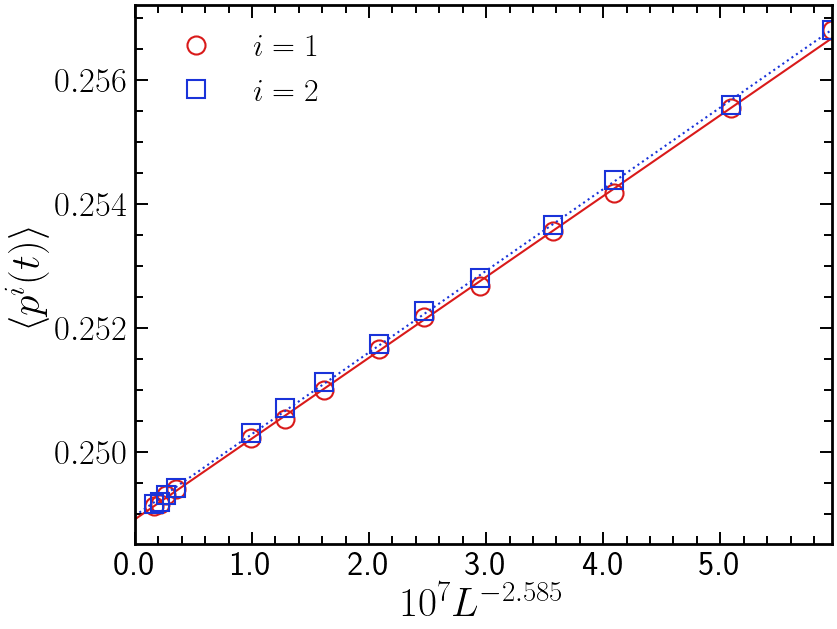

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, MaxNLocator

L_lst = [256, 272, 296, 312, 336, 360, 384, 424, 464, 512, 768, 849, 928, 1024]
nc = 2
rho = 1/nc

fs_legend_local = 23
fs_ticks = 25
fs_labels = 30
mew = 1.5
ms = 13

markers = ["o","s","^","v","D","P","X","*"]

colors = [
    (0.85, 0.10, 0.10),
    (0.10, 0.20, 0.85),
]

ls = ['solid', 'dotted', 'dashed', 'dashdot']

orders = [i for i in range(1, nc+1)]

fig, ax = plt.subplots(figsize=(9, 7))

l = np.asarray([1/i for i in L_lst], float)

data = {"order": [], "A": [], "sigma_A": [], "B": [], "sigma_B": [], "nu": [], "R²": []}
nu = np.linspace(0.1, 6.1, 100)
ns_latex = []
l_latex = []
# =========================
# Encontrar melhor expoente
# =========================plt.savefig(path_sizes + f"/L_versus_p_nc_{nc}.pdf")
for idx, ord in enumerate(orders):

    pc_lst = []
    pc_err_lst = []

    for L in L_lst:
        df_sub = df[(df['L']==L)&(df['nc']==nc)&(df['rho']==rho)&(df['order']==ord)]
        pc_lst.append(df_sub['p_mean'].values[0])
        pc_err_lst.append(df_sub['p_err'].values[0])
    
        if(ord == 1):
            ns_latex.append(df_sub["N_samples"].values[0])
            l_latex.append(L)
    
    pc_lst = np.asarray(pc_lst,float)
    pc_err_lst = np.asarray(pc_err_lst,float)

    for ni in nu:
        x = np.asarray([1/(L**ni) for L in L_lst],float)
        parms = linear_regression_weighted(x, pc_lst, pc_err_lst)

        data["order"].append(ord)
        data["nu"].append(ni)
        data["R²"].append(parms[6])
        data["A"].append(parms[0])
        data["B"].append(parms[1])
        data["sigma_A"].append(parms[2])
        data["sigma_B"].append(parms[3])

print(l_latex)
print(ns_latex)
df_new = pd.DataFrame(data)

df_best = (
    df_new.loc[df_new.groupby("order")["R²"].idxmax()]
    .sort_values("order")
    .reset_index(drop=True)
)

exp = df_best["nu"].mean()
print("exp =", exp)
print(df_best)
# =========================
# Escala 10^7
# =========================
power = 7
scale = 10**power

x_base = l**exp
x_scaled = x_base * scale
x_max = float(np.max(x_scaled))

# =========================
# Plot
# =========================
for idx, ord in enumerate(orders):

    pc_lst = []
    pc_err_lst = []

    for L in L_lst:
        df_sub = df[(df['L']==L)&(df['nc']==nc)&(df['rho']==rho)&(df['order']==ord)]
        pc_lst.append(df_sub['p_mean'].values[0])
        pc_err_lst.append(df_sub['p_err'].values[0])

    pc = np.asarray(pc_lst,float)
    pc_err = np.asarray(pc_err_lst,float)

    parms = linear_regression_weighted(x_scaled, pc, pc_err)

    x_fit = np.linspace(0, x_max, 500)
    y_fit = parms[0]*x_fit + parms[1]

    ax.plot(x_fit, y_fit, ls=ls[idx], color=colors[idx])
    ax.plot(x_scaled, pc, linestyle='none',
            marker=markers[idx], ms=ms, mew=mew,
            color=colors[idx],
            label=f'$i = {ord}$')

# =========================
# Ticks limpos
# =========================
ax.xaxis.set_major_locator(MaxNLocator(6))
ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax.xaxis.offsetText.set_visible(False)

ax.set_xlim([0, x_max])

ax.set_xlabel(fr"$10^{{{power}}}L^{{-{exp:.3f}}}$", fontsize=fs_labels)
ax.set_ylabel(r"$\langle p^i(t) \rangle$", fontsize=fs_labels)

ax.legend(fontsize=fs_legend_local)
ax.tick_params(axis='both', which='major', labelsize=fs_ticks)
plt.savefig(path_sizes + f"/L_versus_p_nc_{nc}.pdf")
plt.show()

In [14]:
def format_param_parenthesis(value, error):
    """
    Formato: valor(erro)
    Erro com 1 dígito significativo.
    Nunca usa notação científica.
    """

    if error == 0 or np.isnan(error):
        return f"{value}"

    exponent = int(math.floor(math.log10(abs(error))))
    
    # número de casas decimais necessárias
    decimals = -exponent if exponent < 0 else 0

    # erro com 1 dígito significativo
    error_rounded = round(error, decimals)
    value_rounded = round(value, decimals)

    # converte erro para inteiro na casa correta
    error_int = int(round(error_rounded * 10**decimals))

    # formata valor com número fixo de casas
    value_str = f"{value_rounded:.{decimals}f}"

    return f"{value_str}({error_int})"
def format_legend(A, sigma_A, B, sigma_B, nu):

    A_str = format_param_parenthesis(A, sigma_A)
    B_str = format_param_parenthesis(B, sigma_B)

    return (
        rf"$\nu = {nu:.3f}$" + "\n" +
        rf"$A = {A_str}$" + "\n" +
        rf"$B = {B_str}$"
    )

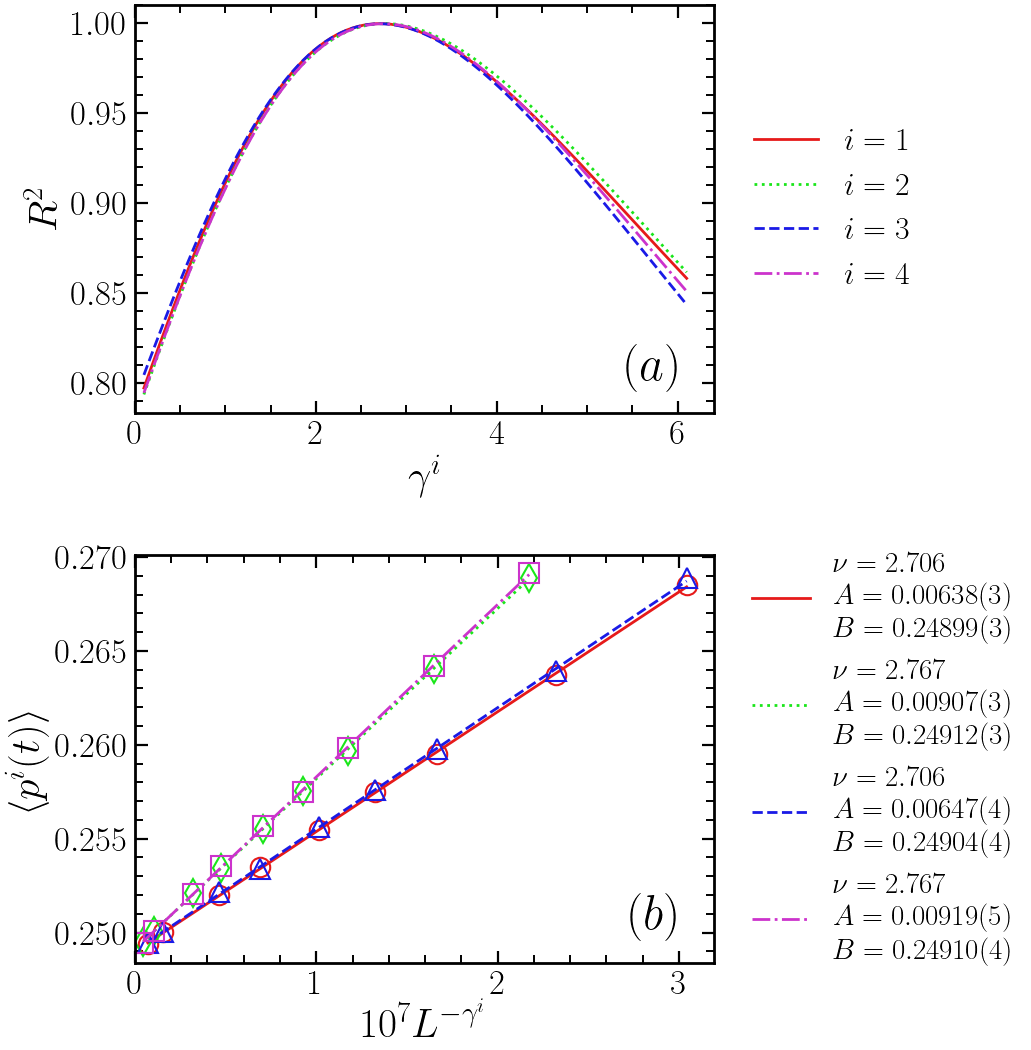

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Espera-se que existam:
# df, df_pi
# linear_regression_weighted(x,y,y_err) -> (A,B,sA,sB,chi2,chi2_red,R2,y_fit)
# format_legend(A, sigma_A, B, sigma_B, nu)

nu = np.linspace(0.1, 6.1, 100)

fs_ticks = 25
fs_labels = 30
lw_data = 2.0
tick_w = 1.6
ms = 14
L_lst = [256, 283, 320, 348, 384, 443, 512, 768, 1024]
markers = ["o", "d", "^", "s", "D", "v"]
colors = [(0.9,0.1,0.1),
          (0.1,0.9,0.1),
          (0.1,0.1,0.9),
          (0.8,0.2,0.8)]

# ======================================================
# Figura 2x1
# ======================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 11))
ax_top = axes[0]
ax_bot = axes[1]
ls = ['solid', 'dotted', 'dashed', 'dashdot', (0, (3, 5, 1, 5)),
      (0, (3, 10, 1, 10)), (5, (10, 3)), (0, (3, 1, 1, 1, 1, 1)),
      (0, (3, 10, 1, 10, 1, 10))]
# ======================================================
# PLOT DE CIMA: R² vs nu (4 curvas)
# ======================================================
data = {"order": [], "A": [], "sigma_A": [], "B": [], "sigma_B": [], "nu": [], "R²": []}
nc = 4
rho = 1/nc
orders = [i for i in range(1, nc+1)]

for idx, ord in enumerate(orders):

    pc_lst = []
    pc_err_lst = []
    for L in L_lst:
        df_sub = df[(df['L'] == L) & (df['nc'] == nc) & (df['rho'] == rho) & (df['order'] == ord)]
        pc_lst.append(df_sub['p_mean'].values[0])
        pc_err_lst.append(df_sub['p_err'].values[0])

    pc_lst = np.asarray(pc_lst, float)
    pc_err_lst = np.asarray(pc_err_lst, float)

    for ni in nu:
        x = np.asarray([1 / (L**ni) for L in L_lst], float)
        y = pc_lst
        y_err = pc_err_lst

        parms = linear_regression_weighted(x, y, y_err)
        A, B, sigma_A, sigma_B, R2 = parms[0], parms[1], parms[2], parms[3], parms[6]

        data["order"].append(ord)
        data["nu"].append(ni)
        data["R²"].append(R2)
        data["A"].append(A)
        data["B"].append(B)
        data["sigma_A"].append(sigma_A)
        data["sigma_B"].append(sigma_B)

df_new = pd.DataFrame(data=data)

df_best_per_order = (
    df_new.loc[df_new.groupby("order")["R²"].idxmax()]
          .sort_values("order")
          .reset_index(drop=True)
)

# curvas R²(nu)
for idx, ord in enumerate(orders):
    df_ord = df_new[df_new["order"] == ord]
    ax_top.plot(df_ord["nu"], df_ord["R²"], lw=lw_data, color=colors[idx], ls=ls[idx], label=fr"$i={ord}$")

ax_top.set_xlabel(r"$\gamma^i$", fontsize=fs_labels)
ax_top.set_ylabel(r"$R^2$", fontsize=fs_labels)
ax_top.tick_params(axis='both', which='major', labelsize=fs_ticks, width=tick_w)
ax_top.set_xlim(0)

# legenda fora (direita), centralizada
leg_top = ax_top.legend(
    bbox_to_anchor=(1.02, 0.5),
    loc='center left',
    frameon=False,
    fontsize=fs_ticks-2
)

# ======================================================
# PLOT DE BAIXO: ajuste com nu ótimo por ordem
#   - eixo x reescalado: x' = 10^7 * L^{-nu}
#   - slope reescalado de forma consistente: A' = A / 10^7
# ======================================================
for index in range(nc):

    L_inv = np.asarray(df_pi.iloc[index]["L_lst"], float)  # já é 1/L
    pc = np.asarray(df_pi.iloc[index]["pc"], float)
    pc_err = np.asarray(df_pi.iloc[index]["pc_err"], float)

    A = df_best_per_order.iloc[index]["A"]
    B = df_best_per_order.iloc[index]["B"]
    nu_best = df_best_per_order.iloc[index]["nu"]
    sigma_A = df_best_per_order.iloc[index]["sigma_A"]
    sigma_B = df_best_per_order.iloc[index]["sigma_B"]

    # variável original
    x0 = L_inv**nu_best

    # reescala para remover ×10^-7 do eixo: x' = 10^7 x0
    x = 1e7 * x0

    # reescala A (e seu erro) para manter o mesmo ajuste em função de x'
    A_plot = A / 1e7
    sigma_A_plot = sigma_A / 1e7
    B_plot = B
    sigma_B_plot = sigma_B

    ax_bot.plot(
        x, pc,
        marker=markers[index],
        linestyle='none',
        color=colors[index],
        ms = ms,
        mew=mew
    )

    x_fit = np.linspace(np.min(x), np.max(x), 200)
    label_text = format_legend(A_plot, sigma_A_plot, B_plot, sigma_B_plot, nu_best)

    ax_bot.plot(
        x_fit, A_plot * x_fit + B_plot,
        color=colors[index],
        lw=2,
        label=label_text
    )

ax_bot.set_xlim(0)
ax_bot.set_xlabel(r"$10^{7} L^{-\gamma^i}$", fontsize=fs_labels)
ax_bot.set_ylabel(r"$\langle p^i(t) \rangle$", fontsize=fs_labels)
ax_bot.tick_params(axis='both', which='major', labelsize=fs_ticks, width=tick_w)

# legenda fora (direita), centralizada
leg_bot = ax_bot.legend(
    bbox_to_anchor=(1.02, 0.5),
    loc='center left',
    frameon=False,
    fontsize=fs_ticks-4
)
labels_alfa = ["$(a)$", "$(b)$"]
fs_text = 35
ax_bot.text(0.95, 0.05, labels_alfa[1],
        transform=ax_bot.transAxes, ha='right', va='bottom',
        fontsize=fs_text)

ax_top.text(0.95, 0.05, labels_alfa[0],
        transform=ax_top.transAxes, ha='right', va='bottom',
        fontsize=fs_text)

#  espaço para as legendas do lado
plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.savefig(path_sizes + f"/R_L_ni_{nc}.pdf")
plt.show()

[1, 2, 3, 4]


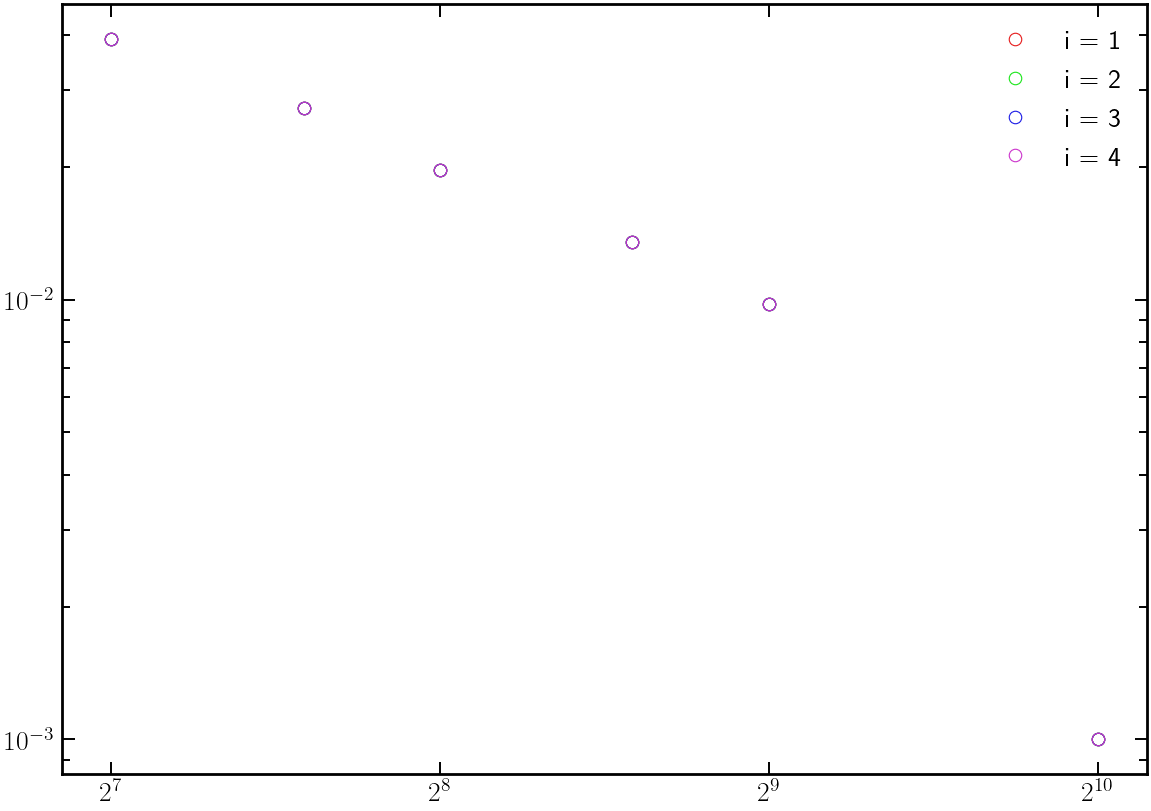

In [22]:
nc = 4
rho = 1/nc
ord = 1
L_unique = np.sort(df[(df['nc'] == nc) & (df['rho'] == rho) & (df['order'] == ord)]['L'].unique())
L_lst = [128, 192, 256, 384, 512, 1024]
orders = [i for i in range(1, nc+1)]
print(orders)
for ord in orders:
    rho_min = [df[(df['nc'] == nc)  & (df['order'] == ord) & (df['L'] == L)]['rho'].min() for L in L_lst]
    plt.plot(L_lst, rho_min, 'o', label=f'i = {ord}')

plt.legend()
plt.xscale('log', base=2)
plt.yscale('log', base=10)
plt.show()
